
# DAY 4 – DECISION TREES & KNN
# Classification using Breast Cancer Wisconsin Dataset




#  IMPORT LIBRARIES


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# LOAD DATASET

In [42]:
data = load_breast_cancer(as_frame=True)
df = data.frame
print("Dataset loaded successfully!")
print("\nFirst 5 rows:")
print(df.head())

Dataset loaded successfully!

First 5 rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  w

# UNDERSTANDING THE DATASET

In [43]:
print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nTarget Classes:")
print(data.target_names)

print("\nMissing Values:")
print(df.isnull().sum().sum())


Dataset Shape:
(569, 31)

Column Names:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension', 'target']

Target Classes:
['malignant' 'benign']

Missing Values:
0


# DISPLAY BASIC INFORMATION

In [44]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness erro

# 5. CHECK TARGET DISTRIBUTION

In [45]:
print("\nTarget Distribution:")
print(df["target"].value_counts())

print("\nTarget Distribution (%):")
print(df["target"].value_counts(normalize=True) * 100)


Target Distribution:
target
1    357
0    212
Name: count, dtype: int64

Target Distribution (%):
target
1    62.741652
0    37.258348
Name: proportion, dtype: float64


# 6. FEATURE AND TARGET SELECTION

In [73]:
X = df.drop("target", axis=1)

# Target variable
y = df["target"]

print("\nInput Features Shape:")
print(X.shape)

print("\nTarget Shape:")
print(y.shape)


Input Features Shape:
(569, 30)

Target Shape:
(569,)


# 7. DISPLAY TARGET MEANING

In [47]:
print("\nTarget Classes:")
print("0 =", data.target_names[0])
print("1 =", data.target_names[1])


Target Classes:
0 = malignant
1 = benign


# 8. TRAIN-TEST SPLIT

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print("\nTraining Data Shape:")
print(X_train.shape)

print("\nTesting Data Shape:")
print(X_test.shape)


Training Data Shape:
(455, 30)

Testing Data Shape:
(114, 30)


# 9. FEATURE SCALING FOR KNN

In [49]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling completed!")


Feature scaling completed!


# 10. DECISION TREE MODEL

In [50]:
print("\n" + "=" * 60)
print("DECISION TREE MODEL")
print("=" * 60)

dt_model = DecisionTreeClassifier(max_depth=4,random_state=42)

# Train Decision Tree
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")


DECISION TREE MODEL
Decision Tree model trained successfully!


# 11. DECISION TREE PREDICTIONS

In [51]:
dt_pred = dt_model.predict(X_test)

print("\nFirst 20 Decision Tree Predictions:")
print(dt_pred[:20])


First 20 Decision Tree Predictions:
[0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 1 1 1 1]


# 12. DECISION TREE EVALUATION

In [52]:
dt_accuracy = accuracy_score(y_test, dt_pred)

dt_precision = precision_score(y_test, dt_pred)

dt_recall = recall_score(y_test, dt_pred)

dt_f1 = f1_score(y_test, dt_pred)


print("\nDecision Tree Evaluation:")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1-Score :", dt_f1)


Decision Tree Evaluation:
Accuracy : 0.9385964912280702
Precision: 0.9577464788732394
Recall   : 0.9444444444444444
F1-Score : 0.951048951048951


# 13. DECISION TREE CLASSIFICATION REPORT

In [53]:
print("\nDecision Tree Classification Report:")

print(classification_report(y_test,dt_pred,target_names=data.target_names))


Decision Tree Classification Report:
              precision    recall  f1-score   support

   malignant       0.91      0.93      0.92        42
      benign       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



# 14. DECISION TREE CONFUSION MATRIX

In [54]:
dt_cm = confusion_matrix(y_test, dt_pred)

print("\nDecision Tree Confusion Matrix:")
print(dt_cm)


Decision Tree Confusion Matrix:
[[39  3]
 [ 4 68]]


# 15. VISUALIZE DECISION TREE

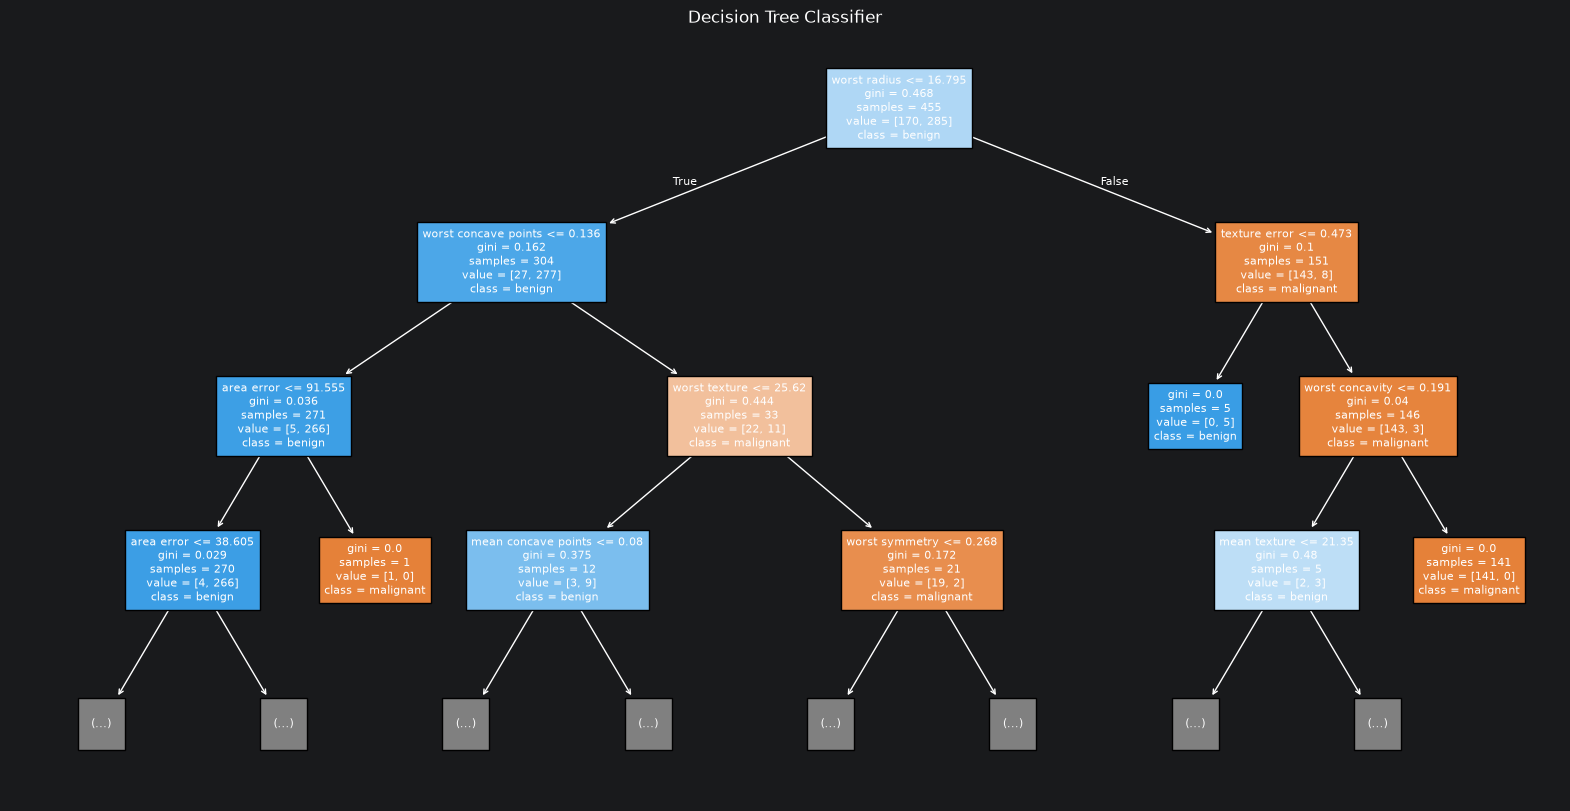

In [55]:
plt.figure(figsize=(20, 10))

plot_tree(dt_model,feature_names=X.columns,class_names=data.target_names,filled=True,max_depth=3,fontsize=8)

plt.title("Decision Tree Classifier")

plt.show()

# 16. FEATURE IMPORTANCE

In [56]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by="Importance",ascending=False)

print("\nTop 10 Important Features:")
print(feature_importance.head(10))


Top 10 Important Features:
                 Feature  Importance
20          worst radius    0.733548
27  worst concave points    0.122028
11         texture error    0.045785
21         worst texture    0.032319
26       worst concavity    0.017161
7    mean concave points    0.013327
13            area error    0.012704
1           mean texture    0.011846
28        worst symmetry    0.011282
3              mean area    0.000000


# 17. FEATURE IMPORTANCE GRAPH

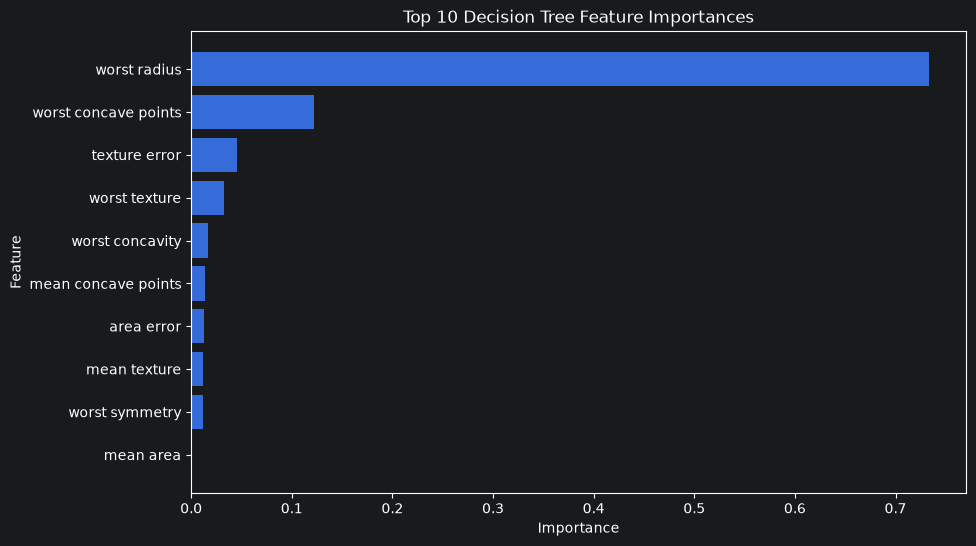

In [57]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(top_features["Feature"][::-1],top_features["Importance"][::-1])

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Decision Tree Feature Importances")

plt.show()

# 18. KNN MODEL

In [58]:
print("\n" + "=" * 60)
print("K-NEAREST NEIGHBORS (KNN) MODEL")
print("=" * 60)

# Create KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train KNN using scaled data
knn_model.fit(X_train_scaled,y_train)

print("KNN model trained successfully!")


K-NEAREST NEIGHBORS (KNN) MODEL
KNN model trained successfully!


# 19. KNN PREDICTIONS

In [59]:
knn_pred = knn_model.predict(X_test_scaled)

print("\nFirst 20 KNN Predictions:")
print(knn_pred[:20])


First 20 KNN Predictions:
[0 1 0 0 0 1 1 0 0 0 1 0 1 0 0 1 1 1 1 1]


# 20. KNN EVALUATION

In [60]:
knn_accuracy = accuracy_score(y_test, knn_pred)

knn_precision = precision_score(y_test, knn_pred)

knn_recall = recall_score(y_test, knn_pred)

knn_f1 = f1_score(y_test, knn_pred)


print("\nKNN Evaluation:")
print("Accuracy :", knn_accuracy)
print("Precision:", knn_precision)
print("Recall   :", knn_recall)
print("F1-Score :", knn_f1)


KNN Evaluation:
Accuracy : 0.956140350877193
Precision: 0.958904109589041
Recall   : 0.9722222222222222
F1-Score : 0.9655172413793104


# 21. KNN CLASSIFICATION REPORT

In [61]:
print("\nKNN Classification Report:")

print(classification_report(y_test,knn_pred,target_names=data.target_names))


KNN Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



# 22. KNN CONFUSION MATRIX

In [62]:
knn_cm = confusion_matrix(y_test, knn_pred)

print("\nKNN Confusion Matrix:")
print(knn_cm)



KNN Confusion Matrix:
[[39  3]
 [ 2 70]]


# 23. COMPARE MODELS

In [63]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],

    "Decision Tree": [
        dt_accuracy,
        dt_precision,
        dt_recall,
        dt_f1
    ],

    "KNN": [
        knn_accuracy,
        knn_precision,
        knn_recall,
        knn_f1
    ]
})

print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

print(comparison)


MODEL COMPARISON
      Metric  Decision Tree       KNN
0   Accuracy       0.938596  0.956140
1  Precision       0.957746  0.958904
2     Recall       0.944444  0.972222
3   F1-Score       0.951049  0.965517


# 24. MODEL COMPARISON GRAPH

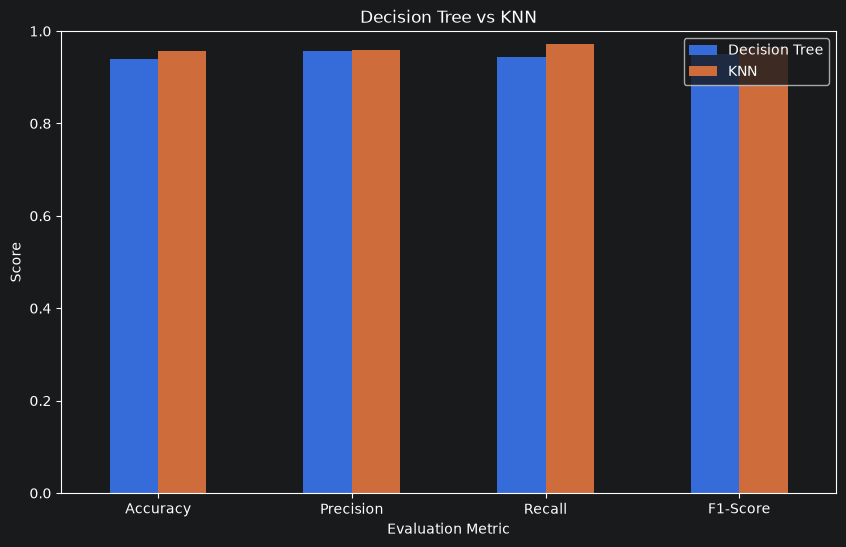

In [64]:
comparison_plot = comparison.set_index("Metric")

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Decision Tree vs KNN")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.legend()

plt.show()

# 25. CONFUSION MATRIX COMPARISON

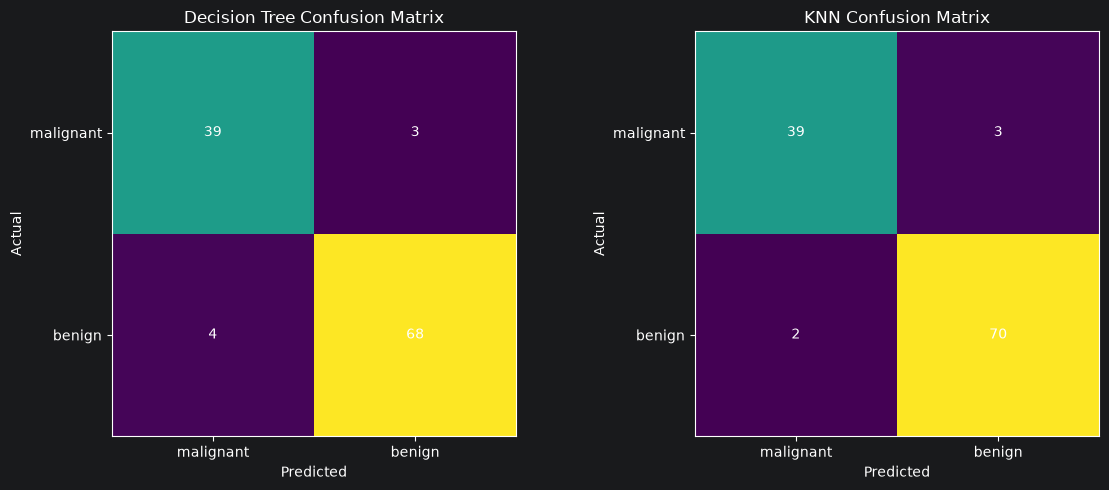

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Decision Tree
axes[0].imshow(dt_cm)

axes[0].set_title("Decision Tree Confusion Matrix")

axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])

axes[0].set_xticklabels(data.target_names)
axes[0].set_yticklabels(data.target_names)

for i in range(2):
    for j in range(2):
        axes[0].text(
            j,
            i,
            dt_cm[i, j],
            ha="center",
            va="center"
        )


# KNN
axes[1].imshow(knn_cm)

axes[1].set_title("KNN Confusion Matrix")

axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])

axes[1].set_xticklabels(data.target_names)
axes[1].set_yticklabels(data.target_names)

for i in range(2):
    for j in range(2):
        axes[1].text(
            j,
            i,
            knn_cm[i, j],
            ha="center",
            va="center"
        )


plt.tight_layout()

plt.show()

# Finding the best K for KNN


In [66]:
k_values=range(1,21)
k_accuracy=[]
for k in k_values:
    model=KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled,y_train)
    predictions=model.predict(X_test_scaled)
    accuracy=accuracy_score(y_test, predictions)
    k_accuracy.append(accuracy)
print("\n" + "=" * 60)
print("K-values testing completed!")
print("\n" + "=" * 60)


K-values testing completed!



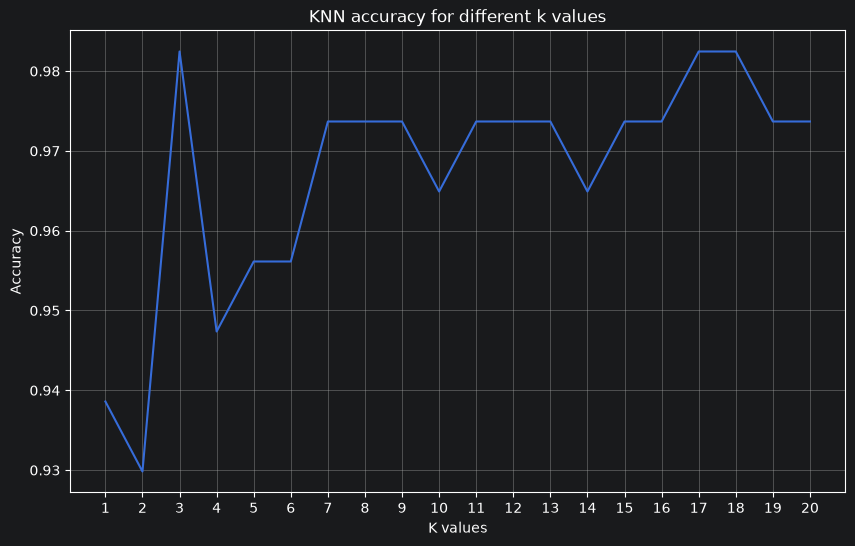

In [67]:
#Plotting K vs accuracy
# 23. Plot K vs Accuracy
plt.figure(figsize=(10, 6))
plt.plot(k_values, k_accuracy)
plt.xlabel("K values")
plt.ylabel("Accuracy")
plt.title("KNN accuracy for different k values")
plt.xticks(k_values)
plt.grid()
plt.show()

In [68]:
#Choosing the best K value
best_k=k_values[np.argmax(k_accuracy)]
print(best_k)

3


# Train a knn model using the new K value

In [69]:
final_knn=KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled,y_train)
print("\n" + "=" * 60)
print("K-NEAREST NEIGHBORS (KNN) MODEL")
print("=" * 60)
print("KNN model trained successfully!")


K-NEAREST NEIGHBORS (KNN) MODEL
KNN model trained successfully!


# PREDICT A NEW SAMPLE

In [70]:
sample = X_test.iloc[[0]]

actual_class = y_test.iloc[0]

# Decision Tree prediction
dt_new_prediction = dt_model.predict(sample)

# KNN prediction
sample_scaled = scaler.transform(sample)

knn_new_prediction = final_knn.predict(
    sample_scaled
)

print("\n" + "=" * 60)
print("NEW SAMPLE PREDICTION")
print("=" * 60)

print("\nActual Class:",
      data.target_names[actual_class])

print(
    "Decision Tree Prediction:",
    data.target_names[dt_new_prediction[0]]
)

print(
    "KNN Prediction:",
    data.target_names[knn_new_prediction[0]]
)



NEW SAMPLE PREDICTION

Actual Class: malignant
Decision Tree Prediction: malignant
KNN Prediction: malignant


In [71]:
#Final Evaluation
final_knn_accuracy=accuracy_score(y_test, final_knn.predict(X_test_scaled))

# 31. DETERMINE BETTER MODEL

In [72]:
print("\n" + "=" * 60)
print("FINAL MODEL COMPARISON")
print("=" * 60)

if dt_accuracy > final_knn_accuracy:

    print("Decision Tree performed better based on Accuracy.")

elif final_knn_accuracy > dt_accuracy:

    print("KNN performed better based on Accuracy.")

else:

    print("Both models achieved the same Accuracy.")


FINAL MODEL COMPARISON
KNN performed better based on Accuracy.
